# Laboratorio 5: Manejo de Archivos y Formatos de Datos (CSV, JSON, Pandas)

Bienvenido al Laboratorio 5. En esta sesión aprenderás a interactuar con el mundo exterior desde Python. Dominarás la lectura y escritura de archivos de texto, el manejo profesional de errores, y el trabajo con formatos estructurados como **CSV** y **JSON**, herramientas esenciales para cualquier Científico de Datos.

## 📋 Tabla de Contenidos

1. [PARTE 1: Abrir archivos](#-parte1)
2. [PARTE 2: Modos de apertura](#-parte2)
3. [PARTE 3: Ejemplo de Buffering](#-parte3)
4. [PARTE 4: Abrir imágenes (PIL)](#-parte4)
5. [PARTE 5: Archivos en simultáneo](#-parte5)
6. [PARTE 6: Archivos CSV](#-parte6)
7. [PARTE 7: Archivos JSON](#-parte7)
8. [PARTE 8: JSON con Pandas](#-parte8)
9. [PARTE 9: Problemas de Aplicación](#-parte9)

---

<a id='-parte1'></a>
## 🔹 PARTE 1: Abrir archivos

### 1.1 Abrir un archivo con `open()`
La forma más básica de abrir un archivo es mediante la función `open()`. Es fundamental cerrar el archivo manualmente para liberar recursos del sistema.

In [1]:
# Ejemplo básico: Abrir, leer y cerrar
try:
    file = open("dog_breeds.txt", "r")
    content = file.read()
    print("Contenido del archivo:")
    print(content)
    file.close() # ¡Importante!
except FileNotFoundError:
    print("El archivo no existe.")

Contenido del archivo:
PUG
JACK RUSSELL TERRIER
ENGLISH SPRINGER SPANIEL
GERMAN SHEPHERD
STAFFORDSHIRE BULL TERRIER
CAVALIER KING CHARLES SPANIEL
GOLDEN RETRIEVER
WEST HIGHLAND WHITE TERRIER
BOXER
BORDER TERRIER
BEAGLE


### 1.2 Manejo de errores con `try / except / else / finally` 
Para un código robusto, debemos anticipar fallos (como que el archivo no exista) y asegurar que el archivo se cierre pase lo que pase.

In [3]:
try:
    file = open("dog_breeds.txt", "r")
    content = file.read()
except FileNotFoundError:
    print("Error: El archivo no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")
else:
    print("Lectura exitosa.")
finally:
    file.close()
    print("Archivo cerrado correctamente.")

Lectura exitosa.
Archivo cerrado correctamente.


### 1.3 Uso de `with open()`
Esta es la **forma recomendada** en Python. El gestor de contexto (`with`) garantiza que el archivo se cierre automáticamente al finalizar el bloque, incluso si ocurre un error.

In [4]:
# Elegante, seguro y eficiente
with open("dog_breeds.txt", "r") as file:
    data = file.read()
    print("Archivo leído automáticamente con 'with'.")

# Aquí el archivo ya está cerrado.

Archivo leído automáticamente con 'with'.


---

<a id='-parte2'></a>
## 🔹 PARTE 2: Modos de apertura (Texto)

Python ofrece diferentes modos para interactuar con los archivos según la necesidad:

| Modo | Descripción | Comportamiento |
| :--- | :--- | :--- |
| `r` | **Read** | Solo lectura (valor por defecto). Error si no existe. |
| `w` | **Write** | Escritura. Sobrescribe el archivo o lo crea si no existe. |
| `a` | **Append** | Añade contenido al final del archivo sin borrar lo anterior. |
| `x` | **Create** | Crea un archivo nuevo. Falla si ya existe. |
| `+` | **Updating** | Permite lectura y escritura simultánea (ej: `r+`, `w+`). |

In [8]:
# Ejemplo Modo 'w' (Escritura)
with open("nuevo_archivo.txt", "w", encoding="UTF-8") as f:
    f.write("Hola, este es un archivo creado desde Python.\n")
    print("Resultado esperado: Archivo creado/sobrescrito con éxito.")

Resultado esperado: Archivo creado/sobrescrito con éxito.


In [9]:
# Elegante, seguro y eficiente
with open("nuevo_archivo.txt", "r", encoding="UTF-8") as f:
    data = f.read()
    print(data)
    print("Archivo leído automáticamente con 'with'.")

Hola, este es un archivo creado desde Python.

Archivo leído automáticamente con 'with'.


In [10]:
# Ejemplo Modo 'a' (Añadir)
with open("nuevo_archivo.txt", "a", encoding="UTF-8") as f:
    f.write("Añadiendo una nueva línea sin borrar la anterior.\n")
    print("Resultado esperado: Contenido agregado al final.")

Resultado esperado: Contenido agregado al final.


---

<a id='-parte3'></a>
## 🔹 PARTE 3: Abrir imágenes

Para manipular imágenes de forma profesional, utilizamos la librería `Pillow` (`PIL`). Esto nos permite manejar archivos complejos sin necesidad de lidiar con bytes manualmente.

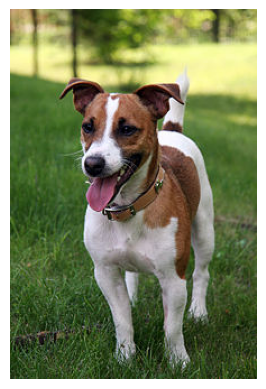

Imagen cargada: PNG, Tamaño: (220, 330)


In [11]:
from PIL import Image
import matplotlib.pyplot as plt

try:
    # Abrimos la imagen directamente
    img = Image.open("jack_russell.png")
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    print(f"Imagen cargada: {img.format}, Tamaño: {img.size}")
except FileNotFoundError:
    print("La imagen 'jack_russell.png' no se encontró.")

---

<a id='-parte4'></a>
## 🔹 PARTE 4: Abrir archivos en simultáneo

Es posible gestionar múltiples archivos en una sola instrucción `with`, lo cual es ideal para procesos de transformación (leer de uno y escribir en otro).

In [12]:
# Procesamiento: Leer entrada, transformar y guardar en salida
with open("dog_breeds.txt", "r") as f_in, open("dog_breeds_upper.txt", "w") as f_out:
    for linea in f_in:
        # Convertimos a mayúsculas y escribimos
        f_out.write(linea.upper())
        
print("Transformación completada con éxito.")

Transformación completada con éxito.


---

<a id='-parte6'></a>
## 🔹 PARTE 6: Archivos CSV

El formato CSV (Comma Separated Values) es el estándar para datos tabulares.

### 6.1 Usando `csv.reader` y `csv.writer`

In [13]:
import csv

In [14]:
# Escribir CSV (Lista de listas)
datos = [["ID", "Nombre"], ["1", "Rex"], ["2", "Toby"]]
with open("perros.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(datos)

In [15]:
# Leer CSV
with open("perros.csv", "r") as f:
    reader = csv.reader(f)
    for fila in reader:
        print(f"Fila: {fila}")

Fila: ['ID', 'Nombre']
Fila: ['1', 'Rex']
Fila: ['2', 'Toby']


### 6.2 Usando `DictReader` y `DictWriter` (Más intuitivo)
Permite trabajar con los datos como si fueran diccionarios, usando los nombres de las columnas.

In [16]:
# Escribir usando diccionarios
with open("empleados.csv", "w", newline="") as f:
    campos = ["nombre", "puesto"]
    writer = csv.DictWriter(f, fieldnames=campos)
    writer.writeheader()
    writer.writerow({"nombre": "Ana", "puesto": "Analista"})

In [17]:
# Leer usando diccionarios
with open("empleados.csv", "r") as f:
    dict_reader = csv.DictReader(f)
    for fila in dict_reader:
        print(f"Nombre: {fila['nombre']}, Puesto: {fila['puesto']}")

Nombre: Ana, Puesto: Analista


### 6.3 CSV con Pandas
Pandas es una herramienta poderosa para el análisis de datos. Permite cargar archivos CSV en un solo paso y realizar operaciones avanzadas de forma eficiente.

In [18]:
import pandas as pd

In [20]:
# Leer un archivo CSV con Pandas
# (Asumiendo que 'perros.csv' fue creado anteriormente)

df = pd.read_csv("perros.csv")
print("DataFrame cargado exitosamente:")
print("\nPrimeras 2 filas:")
print(df.head(2))

DataFrame cargado exitosamente:

Primeras 2 filas:
   ID Nombre
0   1    Rex
1   2   Toby


In [28]:
# Escribir un DataFrame a un nuevo archivo CSV
nuevos_datos = {
    "ID": [10, 11, 12],
    "Nombre": ["Fido", "Luna", "Manchas"],
    "Edad": [3, 5, 2]
}

df_perros = pd.DataFrame(nuevos_datos)

# Guardar sin el índice automático de pandas
df_perros.to_csv("perros_actualizados.csv", index=False)
print("Archivo csv creado exitosamente")

Archivo csv creado exitosamente


---

<a id='-parte7'></a>
## 🔹 PARTE 7: Archivos JSON

JSON es el formato predilecto para el intercambio de datos en la web.

### 7.1 Crear archivo JSON
- `json.dump()`: Guarda el objeto directamente en un **archivo**.
- `json.dumps()`: Convierte el objeto en una **cadena de texto** (string).

In [23]:
import json

In [24]:
data_doc = {"clase": "Python", "laboratorio": 5, "estudiantes": 20}

# dump (a archivo)
with open("config.json", "w") as f:
    json.dump(data_doc, f, indent=4)

# dumps (a string)
json_string = json.dumps(data_doc)
print(f"String JSON: {json_string}")

String JSON: {"clase": "Python", "laboratorio": 5, "estudiantes": 20}


### 7.2 Leer JSON
- `json.load()`: Lee desde un **archivo**.
- `json.loads()`: Lee desde un **string**.

In [25]:
# load (desde archivo)
with open("config.json", "r") as f:
    data_loaded = json.load(f)
    print(f"Cargado desde archivo: {data_loaded['clase']}")

# loads (desde string)
data_from_str = json.loads(json_string)
print(f"Cargado desde string: {data_from_str['laboratorio']}")

Cargado desde archivo: Python
Cargado desde string: 5


### 7.3 JSON con Pandas

Pandas facilita enormemente el trabajo con JSON, especialmente cuando son listas de objetos.

In [26]:
import pandas as pd

In [29]:
# Crear un DataFrame y guardarlo como JSON
df = pd.DataFrame({"fruta": ["Manzana", "Pera"], "precio": [2.5, 1.8]})
df.to_json("frutas.json", orient="records", indent=4)
print("Archivo json creado exitosamente")

Archivo json creado exitosamente


In [31]:
# Leer JSON con Pandas
df_read = pd.read_json("frutas.json")
print("DataFrame desde JSON:\n")
print(df_read)

DataFrame desde JSON:

     fruta  precio
0  Manzana     2.5
1     Pera     1.8


---

<a id='-parte9'></a>
## 🧪 PARTE 9: Problemas de Aplicación

### 📝 Problema 1: El Transformador de Datos
**Enunciado:** 
1. Lee el archivo `dog_breeds.txt`.
2. Filtra las razas que tengan más de 10 caracteres.
3. Guarda el resultado en un archivo CSV llamado `razas_largas.csv` con las columnas `ID` y `Raza`.
4. Si ocurre algún error, infórmalo al usuario.

In [32]:
import csv

try:
    with open("dog_breeds.txt", "r") as fin:
        razas = [linea.strip() for linea in fin if len(linea.strip()) > 10]
    
    with open("razas_largas.csv", "w", newline="") as fout:
        writer = csv.writer(fout)
        writer.writerow(["ID", "Raza"])
        for idx, raza in enumerate(razas, 1):
            writer.writerow([idx, raza])
            
    print("Problema 1: CSV generado correctamente.")
except Exception as e:
    print(f"Error en Problema 1: {e}")

Problema 1: CSV generado correctamente.


### 📝 Problema 2: El Analista de Inventario
**Enunciado:**
1. Crea un archivo JSON llamado `inventario.json` con 3 productos (nombre, stock, precio).
2. Lee ese archivo usando Pandas.
3. Calcula el valor total del inventario (stock * precio).

In [33]:
import json
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 1. Crear JSON
inv = [
    {"nombre": "Laptop", "stock": 5, "precio": 1200},
    {"nombre": "Mouse", "stock": 20, "precio": 25},
    {"nombre": "Monitor", "stock": 10, "precio": 200}
]
with open("inventario.json", "w") as f:
    json.dump(inv, f)

# 2. Leer con Pandas
df_inv = pd.read_json("inventario.json")

# 3. Calcular valor total
df_inv['valor_total'] = df_inv['stock'] * df_inv['precio']
print(df_inv)
print(f"Valor total del inventario: ${df_inv['valor_total'].sum()}")

    nombre  stock  precio  valor_total
0   Laptop      5    1200         6000
1    Mouse     20      25          500
2  Monitor     10     200         2000
Valor total del inventario: $8500
